testing the papers statement about avg pooling layers enabling shift invariance

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [17]:
# cnn max pooling
class MaxPoolCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) 
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # 32 chan * 8x8 image size = 2048 input features??
        self.fc1 = nn.Linear(32 * 8 * 8, 10) 

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        return self.fc1(x)

# the CNN with average pool / "blur"
class AvgPoolCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool1 = nn.AvgPool2d(2, 2) 
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool2 = nn.AvgPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        return self.fc1(x)

In [18]:
def train_model(model, trainloader, model_name, epochs=5):
    print(f"starting training for {model_name} -----")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001) #not sure on best param
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = model(inputs)
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
                
    print(f"Finished Training {model_name}\n")
    return model

In [19]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)

max_model = MaxPoolCNN()
avg_model = AvgPoolCNN()

print("training max cnn model")
max_model = train_model(max_model, trainloader, "MaxPoolCNN", epochs=10)

print("training avg cnn model")
avg_model = train_model(avg_model, trainloader, "AvgPoolCNN", epochs=10)

training max cnn model
starting training for MaxPoolCNN -----
Finished Training MaxPoolCNN

training avg cnn model
starting training for AvgPoolCNN -----
Finished Training AvgPoolCNN



In [ ]:

# from geekforgeek website 
test_set = torchvision.datasets.CIFAR10(root='./data', 
                                        train=False, 
                                        download=True,
                                        transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]))
testloader = torch.utils.data.DataLoader(test_set,
                                          batch_size=4, 
                                          shuffle=True)

images, labels = next(iter(testloader))

test_set_no_shift = test_set


In [22]:
import matplotlib.pyplot as plt

shifts = [0, 1, 2, 3, 4]
test_direction = 'up-left'

max_pool_results = []
avg_pool_results = []

max_model.eval()
avg_model.eval()

print(f"testing models on '{test_direction}' shifts\n\n")

for shift_val in shifts:
    if shift_val == 0:
        current_dataset = test_set_no_shift
    else:
        current_dataset = ControlShiftDataset(test_set, direction=test_direction, shift=shift_val, edge_correction=True)
    
    loader = torch.utils.data.DataLoader(current_dataset, batch_size=64, shuffle=False)
    
    max_acc = test_shift_invariance(max_model, loader)
    avg_acc = test_shift_invariance(avg_model, loader)
    
    max_pool_results.append(max_acc)
    avg_pool_results.append(avg_acc)
    
    print(f"Shift: {shift_val}px | MaxPool acc: {max_acc:.2f}% | AvgPool acc: {avg_acc:.2f}%")

# performance differences
max_baseline = max_pool_results[0]
avg_baseline = avg_pool_results[0]

max_pool_drops = [acc - max_baseline for acc in max_pool_results]
avg_pool_drops = [acc - avg_baseline for acc in avg_pool_results]



testing models on 'up-left' shifts


Shift: 0px | MaxPool acc: 70.43% | AvgPool acc: 67.04%
Shift: 1px | MaxPool acc: 68.45% | AvgPool acc: 65.16%
Shift: 2px | MaxPool acc: 64.93% | AvgPool acc: 61.89%
Shift: 3px | MaxPool acc: 59.09% | AvgPool acc: 56.45%
Shift: 4px | MaxPool acc: 53.31% | AvgPool acc: 49.73%


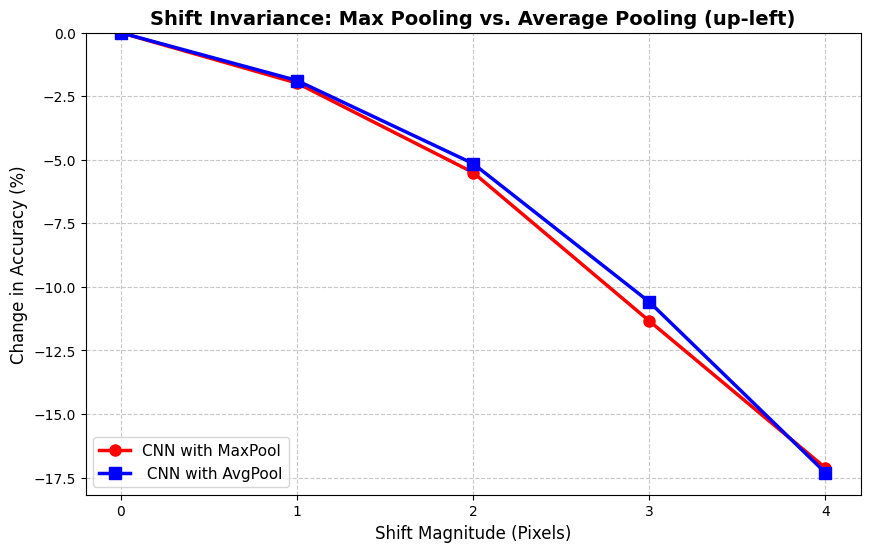

In [23]:

plt.figure(figsize=(10, 6))

plt.plot(shifts, max_pool_drops, marker='o', color='red', linewidth=2.5, markersize=8, label="CNN with MaxPool")

plt.plot(shifts, avg_pool_drops, marker='s', color='blue', linewidth=2.5, markersize=8, label=" CNN with AvgPool")

plt.title(f'Shift Invariance: Max Pooling vs. Average Pooling ({test_direction})', fontsize=14, fontweight='bold')
plt.xlabel('Shift Magnitude (Pixels)', fontsize=12)
plt.ylabel('Change in Accuracy (%)', fontsize=12)
plt.xticks(shifts)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11, loc='lower left')

plt.ylim(top=0)

plt.show()